# Lecture 3. Optimality conditions

**Convex optimization, Fall 2026**

Lecture 2 built convex functions by nonnegative combination, affine precomposition, and legal composition.
We start this lecture with a model: a network that is convex in a designated input.


## Input-convex neural networks

A feedforward net is an arbitrary composition, and lecture 2 said that need not be convex. An **input-convex neural network** (ICNN) is a net whose layers are restricted so that the composition rules apply in a designated input $\mathbf{y}$.

One hidden layer at a time (Amos, Xu, Kolter):

$$
\mathbf{z}_{1}=g_{0}\bigl(\mathbf{W}_{0}^{(y)}\mathbf{y}+\mathbf{b}_{0}\bigr),\qquad
\mathbf{z}_{i+1}=g_{i}\bigl(\mathbf{W}_{i}^{(z)}\mathbf{z}_{i}+\mathbf{W}_{i}^{(y)}\mathbf{y}+\mathbf{b}_{i}\bigr).
$$

The scalar output is an affine function of the last $\mathbf{z}$ and of $\mathbf{y}$.

- Each $g_i$ is convex, nondecreasing, and differentiable: softplus.
- Each $\mathbf{W}_{i}^{(z)}$ is elementwise nonnegative, so $\mathbf{z}_i\mapsto\mathbf{W}_{i}^{(z)}\mathbf{z}_i$ is a nonnegative combination of convex functions.
- Each $\mathbf{W}_{i}^{(y)}$ is free. $\mathbf{y}\mapsto\mathbf{W}_{i}^{(y)}\mathbf{y}+\mathbf{b}_i$ is affine, and affine precomposition preserves convexity.
- The same rules with a context $\mathbf{x}$ in the bias and in $\mathbf{W}^{(y)}$ give a **partially** input-convex net: convex in $\mathbf{y}$ for every fixed $\mathbf{x}$, unrestricted in $\mathbf{x}$.


## Why an ICNN is a useful model

Convexity here is a property of the **prediction problem**, not of training.

- A decoder $\mathbf{y}^\star(\mathbf{x})=\arg\min_{\mathbf{y}} f_\theta(\mathbf{y},\mathbf{x})$ is a convex program in $\mathbf{y}$. A local minimum is global, and $f'_{\mathbf{y}}(\mathbf{y}^\star,\mathbf{x})=\mathbf{0}$ is a certificate.
- Structured prediction: $f_\theta(\cdot,\mathbf{x})$ is a learned energy. Decoding stays a convex optimization problem instead of a combinatorial search.
- Control: a convex stage cost or terminal cost keeps a finite-horizon planner convex, so the learned model can be dropped into a solver from this course.

You do not write the convex function by hand. You keep the calculus of lecture 2, and you let data choose the weights inside that calculus.


## What the architecture does not give you

The nonnegative-weight rule is sufficient, in the same way DCP, from lecture 2, is sufficient. It is not a description of every convex function.

- Drop the direct terms $\mathbf{W}_{i}^{(y)}\mathbf{y}$ and the class collapses. Nonnegative $\mathbf{W}^{(z)}$ can only mix convex hidden units; it cannot aim the function in a new direction. The passthrough is part of the theorem, not an implementation detail.
- Convexity is in $\mathbf{y}$, not in the parameters $\theta$. Learning $\theta$ is an ordinary nonconvex training problem. The certificate applies at inference time.
- Nonnegative weights are an awkward constraint for gradient training. Entries sit at $0$.
- Joint convexity in $(\mathbf{x},\mathbf{y})$ is a smaller class. Most applications want convexity in the decision $\mathbf{y}$ and a free context $\mathbf{x}$. Forcing both is often the wrong model.
- Every prediction solves an optimization problem. That is cheaper than combinatorial inference and more expensive than one forward pass of an unrestricted net.


Matplotlib is building the font cache; this may take a moment.


legal Wz > 0:    max(f - chord) =  0.00e+00  (graph stays under the chord)
illegal Wz < 0:  max(f - chord) =  1.08e+00  (graph rises above the chord)


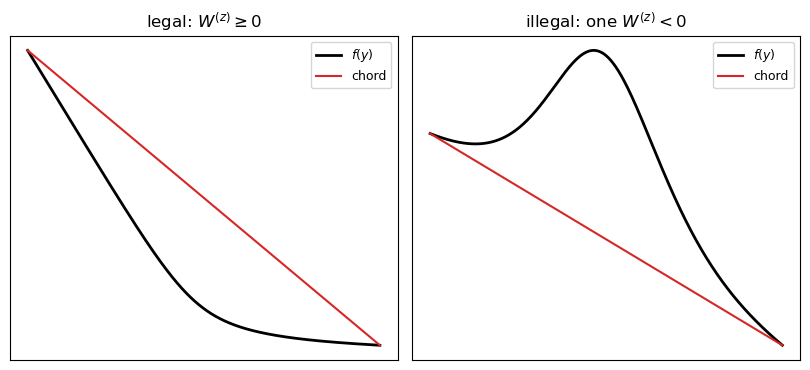

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# A one-dimensional ICNN, and the same net with one illegal negative weight.
def softplus(u):
    return np.logaddexp(0.0, u)

def icnn_1d(y, Wz, Wy, b, w_out):
    z = softplus(Wy[0] * y + b[0])
    z = softplus(Wz * z + Wy[1] * y + b[1])
    return w_out * z + Wy[2] * y + b[2]

y = np.linspace(-3.0, 3.0, 600)
Wy = np.array([-2.38, -1.25, -0.21])
b = np.array([-0.29, 0.31, -0.24])
w_out = 2.09
f_ok = icnn_1d(y, Wz=1.13, Wy=Wy, b=b, w_out=w_out)
f_bad = icnn_1d(y, Wz=-1.13, Wy=Wy, b=b, w_out=w_out)

def chord(f):
    return np.interp(y, [y[0], y[-1]], [f[0], f[-1]])

print(f"legal Wz > 0:    max(f - chord) = {np.max(f_ok - chord(f_ok)): .2e}  (graph stays under the chord)")
print(f"illegal Wz < 0:  max(f - chord) = {np.max(f_bad - chord(f_bad)): .2e}  (graph rises above the chord)")

fig, axes = plt.subplots(1, 2, figsize=(8.2, 3.8))
for ax, f, title in (
    (axes[0], f_ok, r"legal: $W^{(z)}\geq 0$"),
    (axes[1], f_bad, r"illegal: one $W^{(z)}<0$"),
):
    ax.plot(y, f, color="k", lw=2, label="$f(y)$")
    ax.plot(y, chord(f), color="C3", lw=1.5, label="chord")
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])
fig.tight_layout()
plt.show()


### References

- B. Amos, L. Xu, J. Z. Kolter, [*Input convex neural networks*](https://arxiv.org/abs/1609.07152), ICML 2017.
- A. Makkuva, A. Taghvaei, S. Oh, J. Lee, [*Optimal transport mapping via input convex neural networks*](https://arxiv.org/abs/1908.10962), ICML 2020.
- C.-W. Huang, R. T. Q. Chen, C. Tsirigotis, A. Courville, [*Convex potential flows*](https://arxiv.org/abs/2012.05942), ICLR 2021.


# Optimality conditions

**Convex optimization, Fall 2026**

The slides above close lecture 2: an input-convex net, certified by $f'_{\mathbf{y}}(\mathbf{y}^\star,\mathbf{x})=\mathbf{0}$. Lecture 2 certified an unconstrained convex problem by the same test, $f'(\mathbf{x})=\mathbf{0}$.

- A constraint set changes the test.
- The variational inequality replaces a vanishing gradient.
- KKT writes that inequality with multipliers.


## Plan

1. Feasible descent and the variational inequality
2. Equalities and Lagrange multipliers
3. Inequalities and KKT
4. Sufficiency, and Slater's condition for necessity

Notation is lecture 1's. Vectors and matrices are bold. Every function in this lecture is differentiable, and $f'(\mathbf{x})$ is its gradient. $p^\star$ is the optimal value, $\mathbf{x}^\star$ a minimizer.


In [2]:
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt

plt.rcParams.update(
    {
        "figure.figsize": (7.2, 4.0),
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 12,
        "axes.titlesize": 13,
        "legend.fontsize": 11,
    }
)


# 1. Feasible descent

On a convex set, optimality is one inequality in the gradient. The rest of the lecture is that inequality, written in coordinates.


## The variational inequality

- Let $C$ be convex and let $f$ be convex and differentiable.
- A direction $\mathbf{v}$ is a **feasible descent direction** at $\mathbf{x}\in C$ when $\mathbf{x}+t\mathbf{v}$ stays in $C$ and $f$ decreases, for every small $t>0$.
- A minimizer has no feasible descent direction. On a convex set this is one inner product: $\mathbf{x}^\star\in C$ minimizes $f$ on $C$ if and only if, for every $\mathbf{y}\in C$,

$$
\langle f'(\mathbf{x}^\star),\mathbf{y}-\mathbf{x}^\star\rangle\ge 0.
$$


## Why the inequality is necessary

- Suppose some feasible $\mathbf{y}$ makes the inner product negative. 
- The segment

$$
\mathbf{z}(t)=(1-t)\mathbf{x}^\star+t\mathbf{y},\qquad t\in[0,1],
$$

stays in $C$, because $C$ is convex. 
- Along that segment

$$
\frac{d}{dt}\Big|_{t=0}f(\mathbf{z}(t))=\langle f'(\mathbf{x}^\star),\mathbf{y}-\mathbf{x}^\star\rangle<0,
$$

so for small $t>0$ the point $\mathbf{z}(t)$ is feasible and $f(\mathbf{z}(t))<f(\mathbf{x}^\star)$. A minimizer admits no such $\mathbf{y}$.

- Convexity of $C$ keeps the test segment inside the feasible set. 
- Differentiability is what turns the decrease of $f$ into the sign of one inner product.


## Why the inequality is sufficient

- A differentiable convex function lies above its tangent. 
- That is the first-order criterion from lecture 2: for every $\mathbf{y}$,

$$
f(\mathbf{y})\ge f(\mathbf{x}^\star)+\langle f'(\mathbf{x}^\star),\mathbf{y}-\mathbf{x}^\star\rangle.
$$

- If the inner product is nonnegative for every $\mathbf{y}\in C$, the right-hand side is at least $f(\mathbf{x}^\star)$, and therefore so is $f(\mathbf{y})$.

Convexity of $f$ is the hypothesis that makes the tangent a global underestimator. With no constraint, $\mathbf{y}-\mathbf{x}^\star$ can point in every direction, and the same inequality forces $f'(\mathbf{x}^\star)=\mathbf{0}$.


# 2. Equalities

The constraint $h(\mathbf{x})=0$ cuts out a manifold. A feasible minimizer is a minimizer of $f$ along every smooth curve that stays on that manifold.


## A curve that stays on the constraint

$$
\begin{array}{ll}
\text{minimize}  & f(\mathbf{x}) \\
\text{subject to}& h(\mathbf{x})=0.
\end{array}
$$

Let $\mathbf{x}^\star$ be feasible and $h'(\mathbf{x}^\star)\neq\mathbf{0}$. Near $\mathbf{x}^\star$ the feasible set

$$
M=\{\mathbf{x}:h(\mathbf{x})=0\}
$$

is a smooth manifold of dimension $n-1$.

Take any smooth curve $\gamma$ on $M$ with $\gamma(0)=\mathbf{x}^\star$. The identity $h(\gamma(t))=0$ says the curve never leaves the constraint. Differentiating at $t=0$ gives its velocity:

$$
\langle h'(\mathbf{x}^\star),\gamma'(0)\rangle=0.
$$

Every tangent vector to $M$ at $\mathbf{x}^\star$ arises as $\gamma'(0)$ for some such curve.


## The objective along that curve

- If $\mathbf{x}^\star$ minimizes $f$ on $M$, then for every curve $\gamma$ on $M$ through $\mathbf{x}^\star$ the scalar function

$$
\varphi(t)=f(\gamma(t))
$$

has a local minimum at $t=0$. 

- Therefore $\varphi'(0)=0$:

$$
\langle f'(\mathbf{x}^\star),\gamma'(0)\rangle=0.
$$

- $f'(\mathbf{x}^\star)$ is orthogonal to every velocity that stays on $M$. 
- Those velocities are the kernel of $h'(\mathbf{x}^\star)$. 
- A vector orthogonal to that whole kernel is a scalar multiple of $h'(\mathbf{x}^\star)$, so there is a multiplier $\nu$ with

$$
f'(\mathbf{x}^\star)+\nu\, h'(\mathbf{x}^\star)=\mathbf{0},\qquad h(\mathbf{x}^\star)=0.
$$


## Detailed explanation of the key fact

Let $\mathbf{a}\neq\mathbf{0}$, and suppose $\langle\mathbf{g},\mathbf{v}\rangle=0$ for every $\mathbf{v}$ with $\langle\mathbf{a},\mathbf{v}\rangle=0$. Then $\mathbf{g}$ is a scalar multiple of $\mathbf{a}$.

**Proof idea**

- Split $\mathbf{g}$ into its part along $\mathbf{a}$ and a remainder:

$$
\lambda=\frac{\langle\mathbf{g},\mathbf{a}\rangle}{\|\mathbf{a}\|_2^2},\qquad \mathbf{w}=\mathbf{g}-\lambda\mathbf{a}.
$$

- The remainder lies in the kernel:

$$
\langle\mathbf{w},\mathbf{a}\rangle=\langle\mathbf{g},\mathbf{a}\rangle-\lambda\|\mathbf{a}\|_2^2=0.
$$

- The hypothesis at $\mathbf{v}=\mathbf{w}$ gives $\langle\mathbf{g},\mathbf{w}\rangle=0$. 

- Expand the same inner product:

$$
\langle\mathbf{g},\mathbf{w}\rangle=\langle\lambda\mathbf{a}+\mathbf{w},\mathbf{w}\rangle=\|\mathbf{w}\|_2^2.
$$

- Hence $\mathbf{w}=\mathbf{0}$ and $\mathbf{g}=\lambda\mathbf{a}$.

- Take $\mathbf{a}=h'(\mathbf{x}^\star)$ and $\mathbf{g}=f'(\mathbf{x}^\star)$. The multiplier on the previous slide is $\nu=-\lambda$.


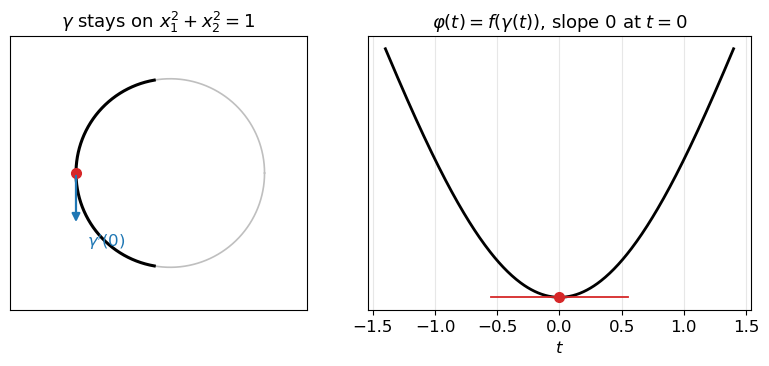

In [3]:
# Minimize x_1 on the circle. Along a curve that stays on the circle, the slope vanishes at the minimizer.
t = np.linspace(-1.4, 1.4, 400)
gamma = np.column_stack((-np.cos(t), -np.sin(t)))  # γ(0) = (-1, 0), and ||γ(t)||_2 = 1
phi = gamma[:, 0]

fig, axes = plt.subplots(1, 2, figsize=(8.2, 3.8))
theta = np.linspace(0, 2 * np.pi, 400)
axes[0].plot(np.cos(theta), np.sin(theta), color="0.75", lw=1.2)
axes[0].plot(gamma[:, 0], gamma[:, 1], color="k", lw=2.2)
axes[0].plot(-1, 0, "o", color="C3", ms=7, zorder=3)
axes[0].annotate(
    "",
    xy=(-1.0, -0.55),
    xytext=(-1.0, 0.0),
    arrowprops=dict(arrowstyle="-|>", color="C0", lw=1.6),
)
axes[0].text(-0.88, -0.78, r"$\gamma'(0)$", color="C0", fontsize=12)
axes[0].set_aspect("equal")
axes[0].set_xlim(-1.7, 1.45)
axes[0].set_ylim(-1.45, 1.45)
axes[0].set_xticks([])
axes[0].set_yticks([])
axes[0].set_title(r"$\gamma$ stays on $x_1^2+x_2^2=1$")

axes[1].plot(t, phi, color="k", lw=2)
axes[1].plot(0, -1, "o", color="C3", ms=7)
axes[1].plot([-0.55, 0.55], [-1, -1], color="C3", lw=1.3)
axes[1].set_xlabel("$t$")
axes[1].set_yticks([])
axes[1].set_title(r"$\varphi(t)=f(\gamma(t))$, slope $0$ at $t=0$")
fig.tight_layout()
plt.show()


## Several equalities, same curves
- Consider several equalities

$$
M=\{\mathbf{x}: h_i(\mathbf{x})=0,\ i=1,\ldots,p\},
$$

with $h_1'(\mathbf{x}^\star),\ldots,h_p'(\mathbf{x}^\star)$ linearly independent. 
- Then $M$ is a manifold of dimension $n-p$.

- A curve on $M$ satisfies $h_i(\gamma(t))=0$ for every $i$, so each constraint kills one component of the velocity:

$$
\langle h_i'(\mathbf{x}^\star),\gamma'(0)\rangle=0,\qquad i=1,\ldots,p.
$$

- Optimality again forces $\langle f'(\mathbf{x}^\star),\gamma'(0)\rangle=0$ for every such velocity. 

- A vector orthogonal to all of them is a linear combination of the constraint gradients:

$$
f'(\mathbf{x}^\star)+\sum_{i=1}^p \nu_i h_i'(\mathbf{x}^\star)=\mathbf{0}.
$$


## Linear combination of the gradients

Let $\mathbf{a}_1,\ldots,\mathbf{a}_p$ be linearly independent, and let

$$
L=\{\mathbf{v}:\langle\mathbf{a}_i,\mathbf{v}\rangle=0\text{ for every }i=1,\ldots,p\}.
$$

Suppose $\langle\mathbf{g},\mathbf{v}\rangle=0$ for every $\mathbf{v}\in L$. Then $\mathbf{g}=\sum_{i=1}^p\lambda_i\mathbf{a}_i$ for a unique $\boldsymbol{\lambda}\in\mathbb{R}^p$.

**Proof idea**

- Let $\mathbf{A}\in\mathbb{R}^{p\times n}$ have rows $\mathbf{a}_i^\top$. 
- Then $L=\ker\mathbf{A}$, and $\mathbf{A}^\top\boldsymbol{\lambda}=\sum_i\lambda_i\mathbf{a}_i$.

- Linear independence makes $\mathbf{A}\mathbf{A}^\top$ invertible. 

- Hence the only solution of the normal equation is

$$
\boldsymbol{\lambda}=(\mathbf{A}\mathbf{A}^\top)^{-1}\mathbf{A}\mathbf{g}.
$$

- Set $\mathbf{w}=\mathbf{g}-\mathbf{A}^\top\boldsymbol{\lambda}$. 
- Then $\mathbf{A}\mathbf{w}=\mathbf{A}\mathbf{g}-\mathbf{A}\mathbf{A}^\top\boldsymbol{\lambda}=\mathbf{0}$, so $\mathbf{w}\in L$. 
- The hypothesis gives $\langle\mathbf{g},\mathbf{w}\rangle=0$, and

$$
\langle\mathbf{g},\mathbf{w}\rangle=\langle\mathbf{A}^\top\boldsymbol{\lambda}+\mathbf{w},\mathbf{w}\rangle=\|\mathbf{w}\|_2^2,
$$

since $\mathbf{A}\mathbf{w}=\mathbf{0}$. 
- Thus $\mathbf{w}=\mathbf{0}$ and $\mathbf{g}=\sum_i\lambda_i\mathbf{a}_i$.

With $\mathbf{a}_i=h_i'(\mathbf{x}^\star)$ and $\mathbf{g}=f'(\mathbf{x}^\star)$, the multipliers on the previous slide are $\nu_i=-\lambda_i$.


## Why the gradients have to be independent

The proof uses linear independence at the moment $\mathbf{A}\mathbf{A}^\top$ is inverted. That invertibility is doing two jobs.

- **The multiplier is unique.** $\mathbf{A}\mathbf{A}^\top$ is invertible exactly when $\mathbf{a}_1,\ldots,\mathbf{a}_p$ are linearly independent. If $\mathbf{a}_2=2\mathbf{a}_1$, then

$$
\nu_1\mathbf{a}_1+\nu_2\mathbf{a}_2=(\nu_1+2\nu_2)\mathbf{a}_1,
$$

so every pair with the same value of $\nu_1+2\nu_2$ satisfies stationarity. A repeated equality does not have a single price.

- **The manifold has dimension $n-p$.** A velocity $\gamma'(0)$ on $M$ satisfies $p$ scalar conditions $\langle h_i'(\mathbf{x}^\star),\gamma'(0)\rangle=0$. Those conditions are independent precisely when the gradients are. The tangent space then has dimension $n-p$, which is the implicit-function description of $M$. If the rank at $\mathbf{x}^\star$ is $r<p$, the tangent space has dimension $n-r$: the extra equalities do not cut the feasible set again.

Dropping duplicate gradients down to a basis of their span, the same decomposition still writes $\mathbf{g}$ as some linear combination. Independence is what makes the coefficients unique and the codimension equal to $p$.


## Minimum-norm point on an affine set

$$
\begin{array}{ll}
\text{minimize}  & \tfrac12\|\mathbf{x}\|_2^2 \\
\text{subject to}& \mathbf{A}\mathbf{x}=\mathbf{b},
\end{array}
$$

with $\mathbf{A}$ of full row rank. 

- Stationarity is $\mathbf{x}+\mathbf{A}^\top\boldsymbol{\nu}=\mathbf{0}$, so $\mathbf{x}=-\mathbf{A}^\top\boldsymbol{\nu}$. 
- Feasibility then gives $\mathbf{A}\mathbf{A}^\top\boldsymbol{\nu}=-\mathbf{b}$, and

$$
\mathbf{x}^\star=\mathbf{A}^\top(\mathbf{A}\mathbf{A}^\top)^{-1}\mathbf{b}.
$$

- One equality $\mathbf{a}^\top\mathbf{x}=b$ collapses to $\mathbf{x}^\star = b\,\mathbf{a}/\|\mathbf{a}\|_2^2$. 
- This is the Euclidean projection onto the hyperplane. 


## Several linear equalities are one linear system

- For smooth $f$ and $\mathbf{A}\mathbf{x}=\mathbf{b}$ with $\mathbf{A}$ of full row rank, KKT is

$$
f'(\mathbf{x})+\mathbf{A}^\top\boldsymbol{\nu}=\mathbf{0},\qquad \mathbf{A}\mathbf{x}=\mathbf{b}.
$$

- Least squares with linear constraints, 
$$
f(\mathbf{x})=\tfrac12\|\mathbf{A}_0\mathbf{x}-\mathbf{b}_0\|_2^2 \to \min_{\mathbf{x}} \quad \text{s.t.} \quad \mathbf{A}\mathbf{x} = \mathbf{b} $$ 

- Stationarity and feasibility are the saddle-point system

$$
\begin{bmatrix}
\mathbf{A}_0^\top\mathbf{A}_0 & \mathbf{A}^\top \\
\mathbf{A} & 0
\end{bmatrix}
\begin{bmatrix}\mathbf{x}\\ \boldsymbol{\nu}\end{bmatrix}
=
\begin{bmatrix}\mathbf{A}_0^\top\mathbf{b}_0\\ \mathbf{b}\end{bmatrix}.
$$

- The matrix is symmetric and indefinite. 
- Factoring it is the whole algorithm. 
- A cone solver, on this problem, is a more general way to build and factor the same block system.


In [3]:
# Equality-constrained least squares: the KKT matrix versus a cone solver.
rng = np.random.default_rng(2)
m, n, p = 12, 6, 2
A0 = rng.normal(size=(m, n))
b0 = rng.normal(size=(m,))
A = rng.normal(size=(p, n))
b = rng.normal(size=(p,))

K = np.block(
    [
        [A0.T @ A0, A.T],
        [A, np.zeros((p, p))],
    ]
)
rhs = np.concatenate([A0.T @ b0, b])
sol = np.linalg.solve(K, rhs)
x_kkt, nu_kkt = sol[:n], sol[n:]

x = cp.Variable(n)
constraint = A @ x == b
problem = cp.Problem(cp.Minimize(0.5 * cp.sum_squares(A0 @ x - b0)), [constraint])
problem.solve(solver=cp.CLARABEL)
nu = np.asarray(constraint.dual_value).ravel()

stationarity = A0.T @ (A0 @ x_kkt - b0) + A.T @ nu_kkt
print(f"||x_kkt - x_solver||     = {np.linalg.norm(x_kkt - x.value):.2e}")
print(f"||ν_kkt - ν_solver||     = {np.linalg.norm(nu_kkt - nu):.2e}")
print(f"stationarity residual    = {np.linalg.norm(stationarity):.2e}")
print(f"feasibility ||Ax-b||     = {np.linalg.norm(A @ x_kkt - b):.2e}")
print(f"cond(KKT matrix)         = {np.linalg.cond(K):.1f}")


||x_kkt - x_solver||     = 1.43e-15
||ν_kkt - ν_solver||     = 8.79e-15
stationarity residual    = 2.55e-15
feasibility ||Ax-b||     = 2.00e-16
cond(KKT matrix)         = 131.3


# 3. Inequalities

- An inequality is included in the linear dependence of $f'_0$ if it is active 
- The multiplier is the coefficient in the linear combination, and it is nonnegative because the feasible side is one-sided.


## KKT

$$
\begin{array}{ll}
\text{minimize}  & f_0(\mathbf{x}) \\
\text{subject to}& f_i(\mathbf{x})\le 0,\quad i=1,\ldots,m,\\
                 & \mathbf{A}\mathbf{x}=\mathbf{b}.
\end{array}
$$


- The **active set** at a feasible $\mathbf{x}$ is $\mathcal{A}(\mathbf{x})=\{i:f_i(\mathbf{x})=0\}$. 
- A point $\mathbf{x}$ together with $\boldsymbol{\lambda}\in\mathbb{R}^m$ and $\boldsymbol{\nu}$ is a **KKT point** when

__1.__ **Stationarity.** $f_0'(\mathbf{x})+\sum_i \lambda_i f_i'(\mathbf{x})+\mathbf{A}^\top\boldsymbol{\nu}=\mathbf{0}$.

__2.__ **Primal feasibility.** $f_i(\mathbf{x})\le 0$ and $\mathbf{A}\mathbf{x}=\mathbf{b}$.

__3.__ **Dual feasibility.** $\boldsymbol{\lambda}\ge \mathbf{0}$.

__4.__ **Complementary slackness.** $\lambda_i f_i(\mathbf{x})=0$ for each $i$.

- Line 1 puts $-f_0'(\mathbf{x})$ in the cone generated by the active gradients and the rows of $\mathbf{A}$. 
- Line 4 sets $\lambda_i=0$ whenever constraint $i$ is slack, so inactive gradients drop out of the sum.


## Why dual feasibility is $\boldsymbol{\lambda}\ge\mathbf{0}$

- An equality keeps both directions of a tangent curve, so its multiplier is free in sign.
- An active inequality $f_i(\mathbf{x}^\star)=0$ keeps one side. A velocity stays feasible only when

$$
\langle f_i'(\mathbf{x}^\star),\mathbf{v}\rangle\le 0,
$$

and optimality forces $\langle f_0'(\mathbf{x}^\star),\mathbf{v}\rangle\ge 0$ for every such $\mathbf{v}$.

- Stationarity is already $f_0'(\mathbf{x}^\star)+ \sum_{i \in \mathcal{A}} \lambda_i f_i'(\mathbf{x}^\star)=\mathbf{0}$ on this constraint. Choose $\mathbf{v}$ tangent to the other active constraints and pointing into this one, so $\langle f_i'(\mathbf{x}^\star),\mathbf{v}\rangle<0$. Then

$$
\langle f_0'(\mathbf{x}^\star),\mathbf{v}\rangle=-\lambda_i\langle f_i'(\mathbf{x}^\star),\mathbf{v}\rangle\ge 0.
$$

- The inner product on the right is negative, so $\lambda_i\ge 0$. A negative multiplier would make this same step a descent direction.
- A slack constraint does not meet the test: complementary slackness sets its multiplier to $0$.


## Projection onto a halfspace

$$
\begin{array}{ll}
\text{minimize}  & \tfrac12\|\mathbf{x}-\mathbf{z}\|_2^2 \\
\text{subject to}& \mathbf{a}^\top\mathbf{x}\le b.
\end{array}
$$

**KKT conditions**

- Stationarity: $\mathbf{x}-\mathbf{z}+\lambda\mathbf{a}=\mathbf{0}$
- Dual feasibility: $\lambda\ge 0$
- Complementary slackness $\lambda(\mathbf{a}^\top\mathbf{x}-b)=0$.

**Different cases**

- If $\mathbf{a}^\top\mathbf{x} < b$, then $\lambda=0$ and $\mathbf{x}^\star=\mathbf{z}$.
- If $\lambda \neq 0$, then $\mathbf{a}^\top \mathbf{x} - b = 0$ and $\mathbf{x} = \mathbf{z}-\lambda\mathbf{a}$

$$
\lambda=\frac{\mathbf{a}^\top\mathbf{z}-b}{\|\mathbf{a}\|_2^2},\qquad
\mathbf{x}^\star=\mathbf{z}-\lambda\mathbf{a}.
$$

The equality case $\mathbf{a}^\top\mathbf{x}=b$ uses the same subtraction with this $\lambda$, and drops the sign restriction $\lambda\ge 0$. One multiplier, closed form.


               z         λ       a·x
(-0.35,  0.15)     0.000    -0.247
( 0.15, -0.55)     0.000    -0.113
( 1.30,  0.60)     0.879     0.550
( 0.30,  1.50)     0.390     0.550
( 1.50, -0.30)     0.657     0.550


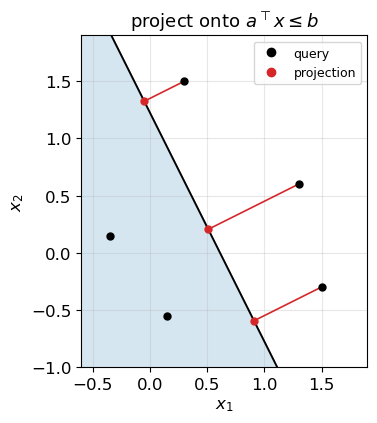

In [4]:
# Euclidean projection onto a halfspace, from the KKT multiplier.
a = np.array([0.9, 0.45])
b = 0.55

def project_halfspace(z, a, b):
    gap = a @ z - b
    if gap <= 0:
        return z.copy(), 0.0
    lam = gap / (a @ a)
    return z - lam * a, lam

points = [
    np.array([-0.35, 0.15]),
    np.array([0.15, -0.55]),
    np.array([1.3, 0.6]),
    np.array([0.3, 1.5]),
    np.array([1.5, -0.3]),
]

print(f"{'z':>16}  {'λ':>8}  {'a·x':>8}")
projected = []
for z in points:
    x_hat, lam = project_halfspace(z, a, b)
    projected.append(x_hat)
    print(f"({z[0]:5.2f}, {z[1]:5.2f})  {lam:8.3f}  {a @ x_hat:8.3f}")

xs = np.linspace(-0.8, 2.0, 400)
ys = np.linspace(-1.2, 2.0, 400)
X1, X2 = np.meshgrid(xs, ys)
feasible = a[0] * X1 + a[1] * X2 <= b

fig, ax = plt.subplots(figsize=(5.2, 4.4))
ax.contourf(X1, X2, feasible.astype(float), levels=[0.5, 1.5], colors=["C0"], alpha=0.18)
boundary = (b - a[0] * xs) / a[1]
ax.plot(xs, boundary, color="k", lw=1.4)
for z, x_hat in zip(points, projected):
    moved = np.linalg.norm(z - x_hat) > 1e-8
    ax.plot(*z, "o", color="k", ms=5, zorder=3)
    if moved:
        ax.plot([z[0], x_hat[0]], [z[1], x_hat[1]], color="C3", lw=1.2)
        ax.plot(*x_hat, "o", color="C3", ms=5, zorder=4)
ax.plot([], [], "o", color="k", label="query")
ax.plot([], [], "o", color="C3", label="projection")
ax.set_aspect("equal")
ax.set_xlim(-0.6, 1.9)
ax.set_ylim(-1.0, 1.9)
ax.set_xlabel(r"$x_1$")
ax.set_ylabel(r"$x_2$")
ax.legend(fontsize=9, loc="upper right")
ax.set_title(r"project onto $a^\top x \leq b$")
fig.tight_layout()
plt.show()


## Projection onto the simplex

A probability vector is the Euclidean projection of a score $\mathbf{z}$ onto $\{\mathbf{x}\ge\mathbf{0}:\mathbf{1}^\top\mathbf{x}=1\}$:

$$
\begin{array}{ll}
\text{minimize}  & \tfrac12\|\mathbf{x}-\mathbf{z}\|_2^2 \\
\text{subject to}& \mathbf{1}^\top\mathbf{x}=1,\quad \mathbf{x}\ge\mathbf{0}.
\end{array}
$$

**KKT conditions**

- Stationarity: $\mathbf{x}-\mathbf{z}+\nu\mathbf{1}-\boldsymbol{\mu}=\mathbf{0}$, 
- Dual feasibility: $\boldsymbol{\mu}\ge\mathbf{0}$
- Complementary slackness: $\mu_i x_i=0$.

**Different cases**

- Case 1: assume $\mu_i = 0$, then $x_i = z_i - \nu \geq 0$
- Case 2: assume $\mu_i > 0$, then $x_i = 0$ and $\mu_i = \nu - z_i$

**The selection of $\nu$ identifies the pairs ($x_i$, $\mu_i$)**

## The threshold, from the multipliers

- Stationarity reads $x_i=z_i-\nu+\mu_i$ in each coordinate. 
- Complementary slackness forces $\mu_i x_i=0$, and both factors are nonnegative, so the sign of $z_i-\nu$ picks one of them:

- if $z_i>\nu$, then $\mu_i=0$ and $x_i=z_i-\nu$;
- if $z_i<\nu$, then $x_i=0$ and $\mu_i=\nu-z_i$;
- if $z_i=\nu$, then $x_i=\mu_i=0$.

Either way,

$$
x_i=\max(z_i-\nu,\,0),\qquad \mu_i=\max(\nu-z_i,\,0).
$$

- The equality $\mathbf{1}^\top\mathbf{x}=1$ is now one equation for the single unknown $\nu$:

$$
\varphi(\nu)=\sum_{i=1}^n\max(z_i-\nu,\,0)=1.
$$



### Properties of $\varphi(\nu)$

- $\varphi$ is continuous. 
- It is strictly decreasing on $(-\infty,\max_i z_i]$
     - at least one term is positive there 
     - each such term has slope $-1$, and $\varphi(\nu)=0$ once $\nu$ passes every entry of $\mathbf{z}$. 
- So exactly one $\nu$ meets the equality. 
- The projection of a closed convex set is unique, and this argument also makes the equality multiplier unique.


## Why one sort finds the threshold

- Let $u_1\ge\cdots\ge u_n$ be the entries of $\mathbf{z}$ in decreasing order, and write $S(j)=\sum_{i=1}^j u_i$. 
- The positive coordinates of $\mathbf{x}$ are the entries of $\mathbf{u}$ that sit strictly above $\nu$. 
- If there are $\rho$ of them,

$$
\sum_{i=1}^{\rho}(u_i-\nu)=1,\qquad \nu=\frac{S(\rho)-1}{\rho}.
$$

- That integer is the largest index whose own formula still lies strictly below $u_j$:

$$
\rho=\max\Bigl\{j: u_j>\frac{S(j)-1}{j}\Bigr\}.
$$

- The set is nonempty: $j=1$ always passes, since $u_1>u_1-1$.

Set $\nu=(S(\rho)-1)/\rho$.

- For every $i\le\rho$, the ordering gives $u_i\ge u_\rho>\nu$. Those $\rho$ entries stay positive, and they sum to $S(\rho)-\rho\nu=1$.
- The next entry cannot sit above the same $\nu$. If $u_{\rho+1}>\nu$, then

$$
\rho\, u_{\rho+1}>S(\rho)-1,
$$

and adding $u_{\rho+1}$ to both sides produces

$$
(\rho+1)\,u_{\rho+1}>S(\rho+1)-1,
$$

so $\rho+1$ would pass the test and $\rho$ would not be maximal. Hence $u_{\rho+1}\le\nu$. Every later entry is smaller still, and is clipped to $0$.

One decreasing sort, one pass over the partial sums, and the threshold on the previous slide is the unique multiplier of $\mathbf{1}^\top\mathbf{x}=1$.


threshold ν (formula) = 0.4500
equality dual          = 0.4500
||x_formula - x_solver|| = 3.60e-08
stationarity residual  = 1.21e-12
complementarity μ·x    = 2.55e-09
μ = [0.   0.25 1.05 0.  ]    max(ν - z, 0) = [0.   0.25 1.05 0.  ]


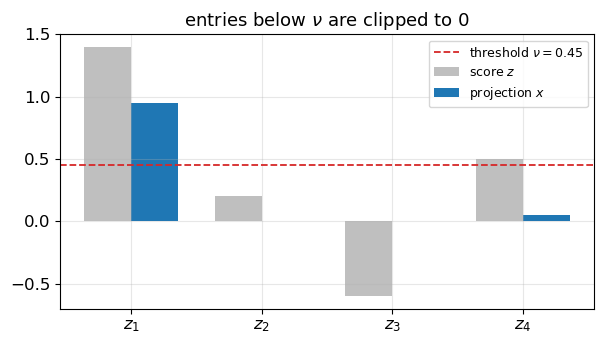

In [5]:
# Simplex projection: the threshold is the equality multiplier.
def project_simplex(z):
    z = np.asarray(z, dtype=float)
    n = z.size
    u = np.sort(z)[::-1]
    cssv = np.cumsum(u)
    rho = np.nonzero(u * np.arange(1, n + 1) > (cssv - 1))[0][-1]
    nu = (cssv[rho] - 1) / (rho + 1.0)
    return np.maximum(z - nu, 0.0), nu

z = np.array([1.4, 0.2, -0.6, 0.5])
x_hat, nu_hat = project_simplex(z)

x = cp.Variable(4)
eq = cp.sum(x) == 1
nonneg = x >= 0
problem = cp.Problem(cp.Minimize(0.5 * cp.sum_squares(x - z)), [eq, nonneg])
problem.solve(solver=cp.CLARABEL)
nu = float(np.asarray(eq.dual_value).ravel()[0])
mu = np.asarray(nonneg.dual_value).ravel()
stationarity = x.value - z + nu * np.ones(4) - mu

print(f"threshold ν (formula) = {nu_hat:.4f}")
print(f"equality dual          = {nu:.4f}")
print(f"||x_formula - x_solver|| = {np.linalg.norm(x_hat - x.value):.2e}")
print(f"stationarity residual  = {np.linalg.norm(stationarity):.2e}")
print(f"complementarity μ·x    = {np.max(np.abs(mu * x.value)):.2e}")
print("μ =", np.round(mu, 3), "   max(ν - z, 0) =", np.round(np.maximum(nu_hat - z, 0), 3))

fig, ax = plt.subplots(figsize=(6.2, 3.6))
idx = np.arange(4)
ax.bar(idx - 0.18, z, width=0.36, color="0.75", label=r"score $z$")
ax.bar(idx + 0.18, x_hat, width=0.36, color="C0", label=r"projection $x$")
ax.axhline(nu_hat, color="C3", lw=1.3, ls="--", label=rf"threshold $\nu={nu_hat:.2f}$")
ax.set_xticks(idx)
ax.set_xticklabels([rf"$z_{i+1}$" for i in idx])
ax.legend(fontsize=9)
ax.set_title(r"entries below $\nu$ are clipped to $0$")
fig.tight_layout()
plt.show()


# 4. When the conditions prove optimality

- For a convex problem, a KKT point is a minimizer. 
- The converse needs one extra hypothesis: a constraint qualification.


## Sufficiency

- Assume $f_0$ and each $f_i$ convex, and the equalities affine. If $\mathbf{x},\boldsymbol{\lambda},\boldsymbol{\nu}$ satisfy KKT, then $\mathbf{x}$ is optimal.

Write the Lagrangian

$$
L(\mathbf{x},\boldsymbol{\lambda},\boldsymbol{\nu})
=f_0(\mathbf{x})+\sum_i\lambda_i f_i(\mathbf{x})+\boldsymbol{\nu}^\top(\mathbf{A}\mathbf{x}-\mathbf{b}).
$$

- $\boldsymbol{\lambda}\ge\mathbf{0}$ and feasibility give $f_0(\mathbf{y})\ge L(\mathbf{y},\boldsymbol{\lambda},\boldsymbol{\nu})$ for every feasible $\mathbf{y}$.
- Stationarity says $\mathbf{x}$ minimizes the convex function $L(\cdot,\boldsymbol{\lambda},\boldsymbol{\nu})$, so $L(\mathbf{y},\boldsymbol{\lambda},\boldsymbol{\nu})\ge L(\mathbf{x},\boldsymbol{\lambda},\boldsymbol{\nu})$.
- Complementary slackness and $\mathbf{A}\mathbf{x}=\mathbf{b}$ give $L(\mathbf{x},\boldsymbol{\lambda},\boldsymbol{\nu})=f_0(\mathbf{x})$.

Therefore $f_0(\mathbf{y})\ge f_0(\mathbf{x})$. A feasible point plus multipliers you can check is the certificate from lecture 1.


## Slater's condition

- KKT is necessary when the constraint gradients are rich enough to describe every feasible direction. 
- For convex inequalities and affine equalities, a workable test is **Slater's condition**: some point satisfies the equalities and lies strictly inside every inequality,

$$
\mathbf{A}\mathbf{x}=\mathbf{b},\qquad f_i(\mathbf{x})<0\quad\text{for all }i.
$$

- Then a minimizer is a KKT point

- An empty interior is a modeling signal: the dual bound may fall short of $p^\star$, and a solver may return a primal point whose multipliers do not satisfy stationarity.


## A convex problem with no multiplier

$$
\begin{array}{ll}
\text{minimize}  & x \\
\text{subject to}& x^2\le 0.
\end{array}
$$

The only feasible point is $x^\star=0$, so $p^\star=0$. The problem is convex. Stationarity at that point would require

$$
1+\lambda\cdot 2x = 1 = 0.
$$

No finite $\lambda$ works. The constraint gradient vanishes at the only feasible point, and the objective gradient there is $1$. Slater's condition fails because $x^2<0$ has no solution.

The next cell asks a solver anyway.


In [15]:
# Slater fails: the solver returns the right primal point and a multiplier that does not certify it.
x = cp.Variable()
constraint = x**2 <= 0
problem = cp.Problem(cp.Minimize(x), [constraint])
problem.solve(solver=cp.CLARABEL)
lam = float(np.asarray(constraint.dual_value).ravel()[0])
x_hat = float(x.value)
print(f"status                     {problem.status}")
print(f"x                          {x_hat:.3e}     (the only feasible point is 0)")
print(f"reported λ                 {lam:.3e}")
print(f"stationarity 1 + 2λx       {1 + 2 * lam * x_hat:.3e}")
print("algebra: at x = 0 the residual is 1, for every finite λ")


status                     optimal
x                          -1.256e-07     (the only feasible point is 0)
reported λ                 3.546e+06
stationarity 1 + 2λx       1.093e-01
algebra: at x = 0 the residual is 1, for every finite λ


## Takeaway

1. On a convex set, $\mathbf{x}^\star$ minimizes a differentiable convex $f$ if and only if $\langle f'(\mathbf{x}^\star),\mathbf{y}-\mathbf{x}^\star\rangle\ge 0$ for every feasible $\mathbf{y}$. Convexity of the set gives necessity. Convexity of $f$ gives sufficiency.
2. KKT writes that inequality with multipliers: stationarity, primal feasibility, dual feasibility $\boldsymbol{\lambda}\ge\mathbf{0}$, complementary slackness. The sign on $\lambda_i$ is the one-sided feasible set of an inequality.
3. Convexity makes a KKT point a minimizer. Slater's condition makes every minimizer a KKT point.
4. Closed forms worth rederiving: halfspace projection and simplex projection.


### References — optimality conditions

- **Book.** S. Boyd and L. Vandenberghe, [*Convex Optimization*](https://web.stanford.edu/~boyd/cvxbook/), Ch. 4.2.3 (the variational inequality) and Ch. 5.5 (KKT).
- **Book.** J. Nocedal and S. Wright, *Numerical Optimization*, Ch. 12, for the same conditions as the stopping test of an algorithm.
- **Lectures.** [EE364a](https://web.stanford.edu/class/ee364a/), optimality conditions.


### References — projections

- J. Duchi, S. Shalev-Shwartz, Y. Singer, T. Chandra, [*Efficient projections onto the $\ell_1$-ball for learning in high dimensions*](https://stanford.edu/~jduchi/projects/DuchiShSiCh08.pdf), ICML 2008. The simplex threshold above is their algorithm, with the radius specialized to $1$.
